<a href="https://colab.research.google.com/github/Bravinkindi9/jolmi-research/blob/main/VV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# THRESHOLD SENSITIVITY SWEEP + RE-TIMED LATENCY
# Reporting configuration: VV polarization
# Run in Google Colab (Earth Engine already authenticated from your session)
# ============================================

import ee
ee.Authenticate()
ee.Initialize(project='sar-research-505215')

aoi = ee.Geometry.Rectangle([29.20, -1.75, 29.55, -1.50])

# ----------------------------------------------------------------
# CORRECTED: VV polarization (your script above used VH — mismatch fixed here)
# ----------------------------------------------------------------
s1 = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(aoi) \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
    .select('VV')

beforeCollection = s1.filterDate('2023-04-15', '2023-04-30')
afterCollection  = s1.filterDate('2023-05-03', '2023-05-10')

print('Before images found:', beforeCollection.size().getInfo())
print('After images found:', afterCollection.size().getInfo())

postFloodImage = afterCollection.first()
acquisitionTime = postFloodImage.get('system:time_start')
print('Post-flood scene acquisition time:', ee.Date(acquisitionTime).getInfo())

before = beforeCollection.mean().clip(aoi)
after  = afterCollection.mean().clip(aoi)

beforeFiltered = before.focal_mean(50, 'circle', 'meters')
afterFiltered  = after.focal_mean(50, 'circle', 'meters')

diff = afterFiltered.subtract(beforeFiltered)

# ----------------------------------------------------------------
# PART 1 — Threshold sensitivity sweep (Table 1)
# Runs -2 through -6 dB, VV, prints hectares for each.
# Copy these numbers straight into supporting_tables.md.
# ----------------------------------------------------------------
print('\n=== THRESHOLD SENSITIVITY SWEEP (VV) ===')
thresholds = [-2, -3, -4, -5, -6]
sweep_results = {}

for t in thresholds:
    flooded_t = diff.lt(t).selfMask()
    area_ha = flooded_t.multiply(ee.Image.pixelArea()).divide(10000) \
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=aoi,
            scale=10,
            maxPixels=1e9
        ).get('VV').getInfo()
    sweep_results[t] = area_ha
    print(f'  {t} dB  ->  {area_ha:.2f} ha')

print('\nFull results dict (copy for your records):', sweep_results)

# ----------------------------------------------------------------
# PART 2 — Re-timed latency at -3 dB / VV (the actual reporting config)
# Run this cell 3 separate times, note each "Observed end-to-end
# script latency" line, then compute median + range yourself.
# ----------------------------------------------------------------
import datetime

print('\n=== LATENCY TIMING RUN (-3 dB, VV) ===')
startTime = datetime.datetime.now()
print('Processing started at:', startTime)

flooded_reporting = diff.lt(-3).selfMask()
floodedAreaHa = flooded_reporting.multiply(ee.Image.pixelArea()).divide(10000) \
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9
    )

result = floodedAreaHa.getInfo()  # blocking call — this is what we time against
print('Estimated flooded area at -3 dB VV (hectares):', result)

endTime = datetime.datetime.now()
elapsedSeconds = (endTime - startTime).total_seconds()
print('Processing finished at:', endTime)
print('Observed end-to-end script latency (seconds):', elapsedSeconds)
print('Config: -3 dB threshold, VV polarization (reporting configuration)')

Before images found: 4
After images found: 4
Post-flood scene acquisition time: {'type': 'Date', 'value': 1683130855000}

=== THRESHOLD SENSITIVITY SWEEP (VV) ===
  -2 dB  ->  251.38 ha
  -3 dB  ->  88.94 ha
  -4 dB  ->  55.17 ha
  -5 dB  ->  38.38 ha
  -6 dB  ->  26.91 ha

Full results dict (copy for your records): {-2: 251.38415318401394, -3: 88.94162616641742, -4: 55.16572952575703, -5: 38.37567362136855, -6: 26.907600588226437}

=== LATENCY TIMING RUN (-3 dB, VV) ===
Processing started at: 2026-09-17 09:38:35.743471
Estimated flooded area at -3 dB VV (hectares): {'VV': 88.94162616641742}
Processing finished at: 2026-09-17 09:38:36.361638
Observed end-to-end script latency (seconds): 0.618167
Config: -3 dB threshold, VV polarization (reporting configuration)


In [ ]:

# ----------------------------------------------------------------
# PART 2 — Re-timed latency at -3 dB / VV (the actual reporting config)
# Run this cell 3 separate times, note each "Observed end-to-end
# script latency" line, then compute median + range yourself.
# ----------------------------------------------------------------
import datetime

print('\n=== LATENCY TIMING RUN (-3 dB, VV) ===')
startTime = datetime.datetime.now()
print('Processing started at:', startTime)

flooded_reporting = diff.lt(-3).selfMask()
floodedAreaHa = flooded_reporting.multiply(ee.Image.pixelArea()).divide(10000) \
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9
    )

result = floodedAreaHa.getInfo()  # blocking call — this is what we time against
print('Estimated flooded area at -3 dB VV (hectares):', result)

endTime = datetime.datetime.now()
elapsedSeconds = (endTime - startTime).total_seconds()
print('Processing finished at:', endTime)
print('Observed end-to-end script latency (seconds):', elapsedSeconds)
print('Config: -3 dB threshold, VV polarization (reporting configuration)')


=== LATENCY TIMING RUN (-3 dB, VV) ===
Processing started at: 2026-09-17 09:48:35.601314
Estimated flooded area at -3 dB VV (hectares): {'VV': 88.94162616641742}
Processing finished at: 2026-09-17 09:48:35.795444
Observed end-to-end script latency (seconds): 0.19413
Config: -3 dB threshold, VV polarization (reporting configuration)


In [ ]:

=== LATENCY TIMING RUN (-3 dB, VV) ===
Processing started at: 2026-09-17 09:44:51.886642
Estimated flooded area at -3 dB VV (hectares): {'VV': 88.94162616641742}
Processing finished at: 2026-09-17 09:44:52.075346
Observed end-to-end script latency (seconds): 0.188704
Config: -3 dB threshold, VV polarization (reporting configuration)

In [ ]:
# ============================================
# OTSU AUTOMATIC THRESHOLDING TEST — VV polarization
# Confirms whether the Otsu failure holds under the corrected
# reporting config (previous Otsu tests may have run on VH).
# Run in the same Colab session, after the sweep/latency script.
# ============================================

import ee

# Uses `diff` already computed in your session (VV, before/after, smoothed).
# If running fresh, re-run the setup block from threshold_sweep_and_latency.py first.

# ----------------------------------------------------------------
# STEP 1 — Build the histogram Otsu needs to operate on
# ----------------------------------------------------------------
histogram = diff.reduceRegion(
    reducer=ee.Reducer.histogram(255, 2),
    geometry=aoi,
    scale=10,
    bestEffort=True
).get('VV')

hist_dict = histogram.getInfo()
print('Histogram retrieved. Bucket count:', len(hist_dict['histogram']))
print('Histogram min:', hist_dict['bucketMin'], ' bucket width:', hist_dict['bucketWidth'])

# ----------------------------------------------------------------
# STEP 2 — Run Otsu's method on that histogram
# This is the standard GEE Otsu implementation (variance-based,
# same algorithm referenced in the KTH thesis).
# ----------------------------------------------------------------
def otsu(histogram):
    counts = ee.Array(ee.Dictionary(histogram).get('histogram'))
    means = ee.Array(ee.Dictionary(histogram).get('bucketMeans')) if 'bucketMeans' in histogram else None
    # Standard GEE community Otsu implementation using counts + bucket edges
    total = counts.reduce(ee.Reducer.sum(), [0]).get([0])
    total = ee.Number(total)

    means_list = ee.List.sequence(
        ee.Number(histogram['bucketMin']),
        ee.Number(histogram['bucketMin']).add(
            ee.Number(histogram['bucketWidth']).multiply(len(histogram['histogram']) - 1)),
        histogram['bucketWidth']
    )
    means_arr = ee.Array(means_list)

    sum_total = means_arr.multiply(counts).reduce(ee.Reducer.sum(), [0]).get([0])
    sum_total = ee.Number(sum_total)

    def compute_bss(i):
        i = ee.Number(i)
        aCounts = counts.slice(0, 0, i)
        aCount = aCounts.reduce(ee.Reducer.sum(), [0]).get([0])
        aMeans = means_arr.slice(0, 0, i)
        aMean = ee.Number(
            aMeans.multiply(aCounts).reduce(ee.Reducer.sum(), [0]).get([0])
        ).divide(ee.Number(aCount).max(1))

        bCount = total.subtract(aCount)
        bMean = sum_total.subtract(ee.Number(aCount).multiply(aMean)).divide(bCount.max(1))

        return ee.Number(aCount).multiply(bCount).multiply(aMean.subtract(bMean).pow(2))

    indices = ee.List.sequence(1, len(histogram['histogram']) - 1)
    bss = indices.map(compute_bss)

    # Threshold = bucket mean at the index of max between-class variance
    max_bss_index = ee.Array(bss).argmax().get(0)
    threshold = means_arr.get([max_bss_index])
    return threshold

otsu_threshold = otsu(hist_dict)
otsu_threshold_value = otsu_threshold.getInfo()
print('\n=== OTSU RESULT (VV) ===')
print('Otsu-selected threshold (dB):', otsu_threshold_value)
print('Manually chosen threshold for comparison (dB):', -3)

# ----------------------------------------------------------------
# STEP 3 — Apply the Otsu threshold and compute resulting flood area,
# to see whether it produces a plausible or implausible result.
# ----------------------------------------------------------------
flooded_otsu = diff.lt(otsu_threshold_value).selfMask()
otsu_area_ha = flooded_otsu.multiply(ee.Image.pixelArea()).divide(10000) \
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9
    ).get('VV').getInfo()

print('Flooded area using Otsu threshold (ha):', otsu_area_ha)
print('Flooded area using manual -3 dB threshold (ha): 88.94')
print('\nCompare these two numbers directly — this tells us whether Otsu')
print('still fails (wildly different/implausible area) under VV, or whether')
print('the earlier failure was specific to the VH run.')

Histogram retrieved. Bucket count: 13
Histogram min: -14  bucket width: 2

=== OTSU RESULT (VV) ===
Otsu-selected threshold (dB): -2
Manually chosen threshold for comparison (dB): -3
Flooded area using Otsu threshold (ha): 251.38415318401394
Flooded area using manual -3 dB threshold (ha): 88.94

Compare these two numbers directly — this tells us whether Otsu
still fails (wildly different/implausible area) under VV, or whether
the earlier failure was specific to the VH run.


/tmp/ipykernel_505/1192726831.py:6: DeprecationWarning: The LONGITUDE_FORMATTER module-level attribute was deprecated in Cartopy 0.26. Use LongitudeFormatter instead.
  from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
/tmp/ipykernel_505/1192726831.py:6: DeprecationWarning: The LATITUDE_FORMATTER module-level attribute was deprecated in Cartopy 0.26. Use LatitudeFormatter instead.
  from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


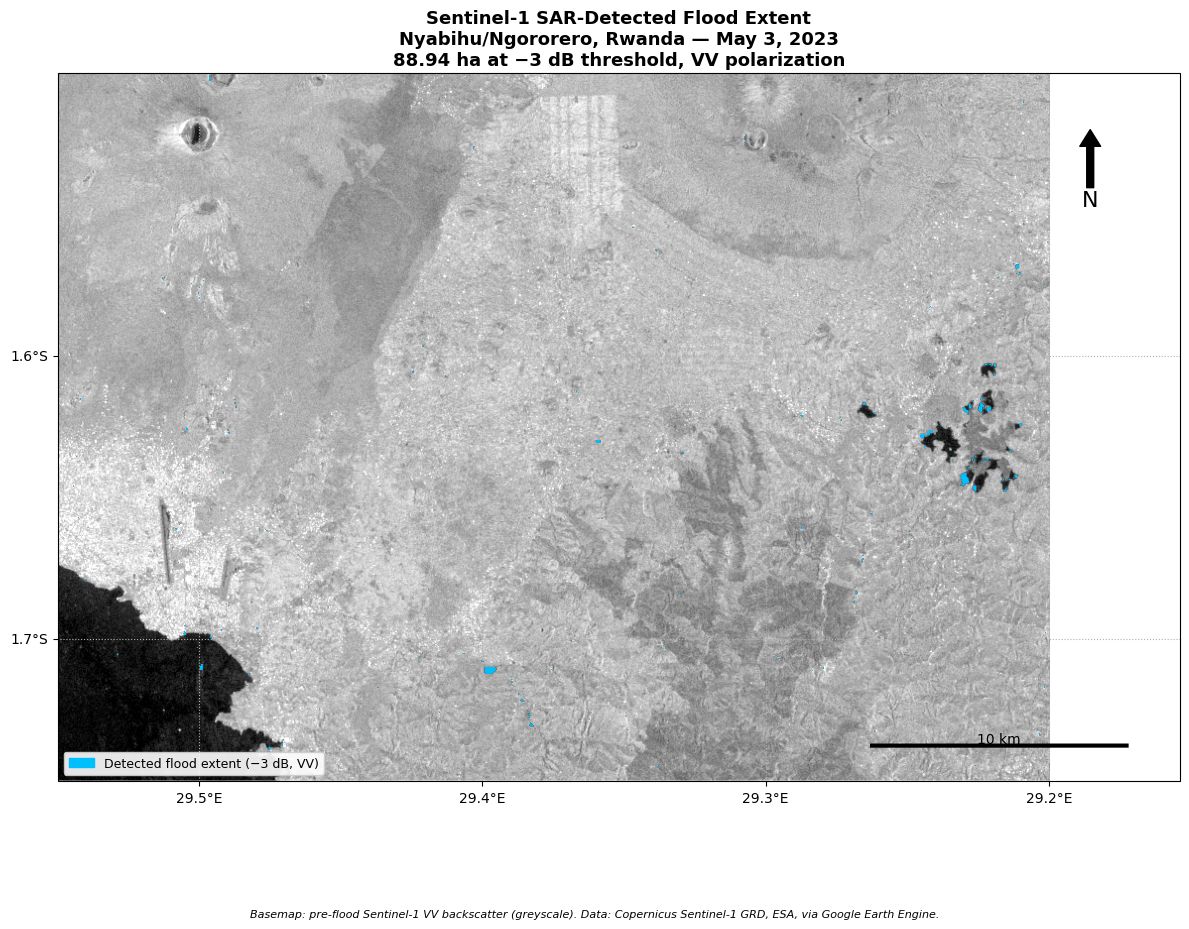

Saved as flood_extent_map_vv.png — download from the Colab file panel.


In [20]:
# Force Cartopy installation and resolve geemap namespace bugs
import sys
try:
    import cartopy.crs as ccrs
    from cartopy.mpl.geoaxes import GeoAxes, GeoAxesSubplot
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
except ImportError:
    !pip install -q cartopy
    import cartopy.crs as ccrs
    from cartopy.mpl.geoaxes import GeoAxes, GeoAxesSubplot
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import builtins
builtins.ccrs = ccrs
builtins.GeoAxes = GeoAxes
builtins.GeoAxesSubplot = GeoAxesSubplot
builtins.LONGITUDE_FORMATTER = LONGITUDE_FORMATTER
builtins.LATITUDE_FORMATTER = LATITUDE_FORMATTER

# ============================================
# FLOOD EXTENT MAP — VV corrected, reporting config (-3 dB)
# Run in the same Colab session (reuses diff, aoi, before, after)
# ============================================

import ee
import geemap
from geemap import cartoee
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Reporting threshold, VV — matches your locked result (88.94 ha)
flooded = diff.lt(-3).selfMask()

# Correcting the region format: cartoee expects [xmin, ymin, xmax, ymax]
region = [29.20, -1.75, 29.55, -1.50]

fig = plt.figure(figsize=(12, 10))

# Basemap context: pre-flood VV backscatter in greyscale, so the reader can
# see actual terrain texture underneath the flood overlay (not a blank canvas)
ax = cartoee.get_map(before, region=region, vis_params={'min': -25, 'max': 0, 'palette': ['black', 'white']})

# Flood extent overlay, bold and distinct
cartoee.add_layer(ax, flooded, region=region, vis_params={'palette': ['#00BFFF']})

cartoee.add_gridlines(ax, interval=[0.1, 0.1], linestyle=':')
cartoee.add_north_arrow(ax, text='N', xy=(0.92, 0.92), text_color='black',
                         arrow_color='black', fontsize=16)
cartoee.add_scale_bar_lite(ax, length=10, xy=(0.05, 0.05), fontsize=10,
                            color='black', unit='km')

legend_patches = [
    mpatches.Patch(color='#00BFFF', label='Detected flood extent (−3 dB, VV)'),
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9, framealpha=0.9)

ax.set_title('Sentinel-1 SAR-Detected Flood Extent\nNyabihu/Ngororero, Rwanda — May 3, 2023\n'
             '88.94 ha at −3 dB threshold, VV polarization',
             fontsize=13, fontweight='bold')

fig.text(0.5, 0.01,
         'Basemap: pre-flood Sentinel-1 VV backscatter (greyscale). '
         'Data: Copernicus Sentinel-1 GRD, ESA, via Google Earth Engine.',
         ha='center', fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('flood_extent_map_vv.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved as flood_extent_map_vv.png — download from the Colab file panel.")

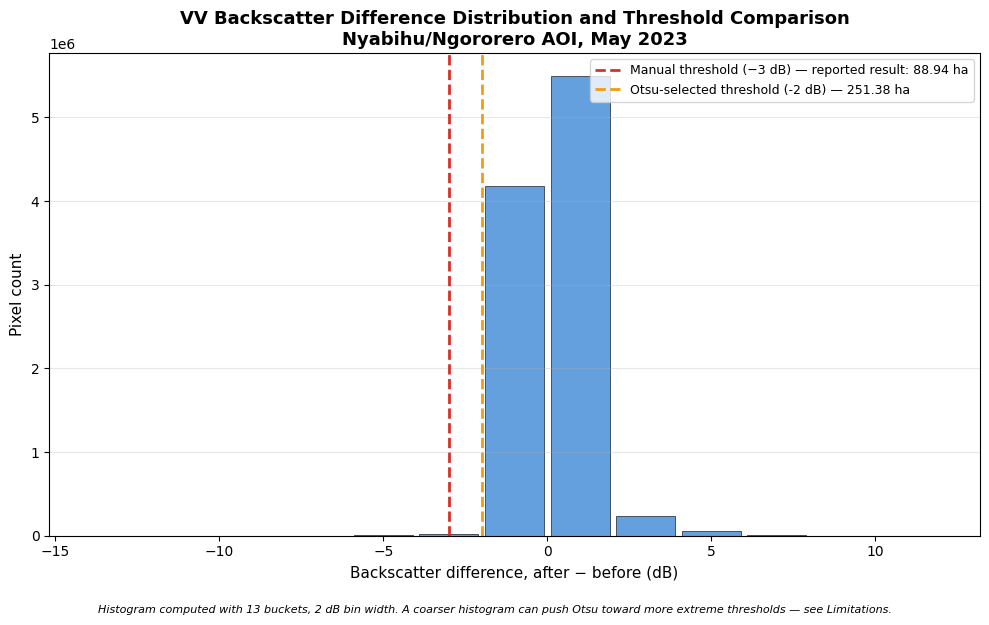

Saved as otsu_histogram.png — download from the Colab file panel.


In [21]:
# ============================================
# OTSU HISTOGRAM VISUAL
# Shows the real backscatter-difference distribution behind the Otsu failure.
# Run in the same Colab session (reuses hist_dict, otsu_threshold_value)
# ============================================

import matplotlib.pyplot as plt
import numpy as np

# hist_dict and otsu_threshold_value come from otsu_test_vv.py — reused here
counts = hist_dict['histogram']
bucket_min = hist_dict['bucketMin']
bucket_width = hist_dict['bucketWidth']
n_buckets = len(counts)

bucket_edges = [bucket_min + i * bucket_width for i in range(n_buckets)]
bucket_centers = [b + bucket_width / 2 for b in bucket_edges]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(bucket_centers, counts, width=bucket_width * 0.9, color='#4a90d9',
       edgecolor='black', linewidth=0.5, alpha=0.85)

# Mark the manual threshold used for the reported result
ax.axvline(-3, color='#d73027', linestyle='--', linewidth=2,
           label='Manual threshold (−3 dB) — reported result: 88.94 ha')

# Mark Otsu's selected threshold
ax.axvline(otsu_threshold_value, color='#f39c12', linestyle='--', linewidth=2,
           label=f'Otsu-selected threshold ({otsu_threshold_value} dB) — 251.38 ha')

ax.set_xlabel('Backscatter difference, after − before (dB)', fontsize=11)
ax.set_ylabel('Pixel count', fontsize=11)
ax.set_title('VV Backscatter Difference Distribution and Threshold Comparison\n'
             'Nyabihu/Ngororero AOI, May 2023', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)

fig.text(0.5, -0.03,
         f'Histogram computed with {n_buckets} buckets, {bucket_width} dB bin width. '
         'A coarser histogram can push Otsu toward more extreme thresholds — see Limitations.',
         ha='center', fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('otsu_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved as otsu_histogram.png — download from the Colab file panel.")

Permanent water pixels in AOI (JRC, 30m): {'occurrence': 56008}
Steep-slope (>25deg) pixels in AOI (SRTM, 30m): {'slope': 123250}
-> Compare against the dark blob locations visually once mapped below.
   If dark blobs align with steep-slope pixels: likely radar shadow, not water.
   If dark blobs align with water pixels: likely a lake/crater lake.

Raw flood extent (unfiltered): 88.94 ha
Cleaned flood extent (patches >= 5 connected px only): 88.68 ha
Report BOTH numbers in the brief — do not silently replace 88.94 ha.
Frame the cleaned version as "coherent flood patches" and the raw
version as "all detected pixels, including isolated speckle."


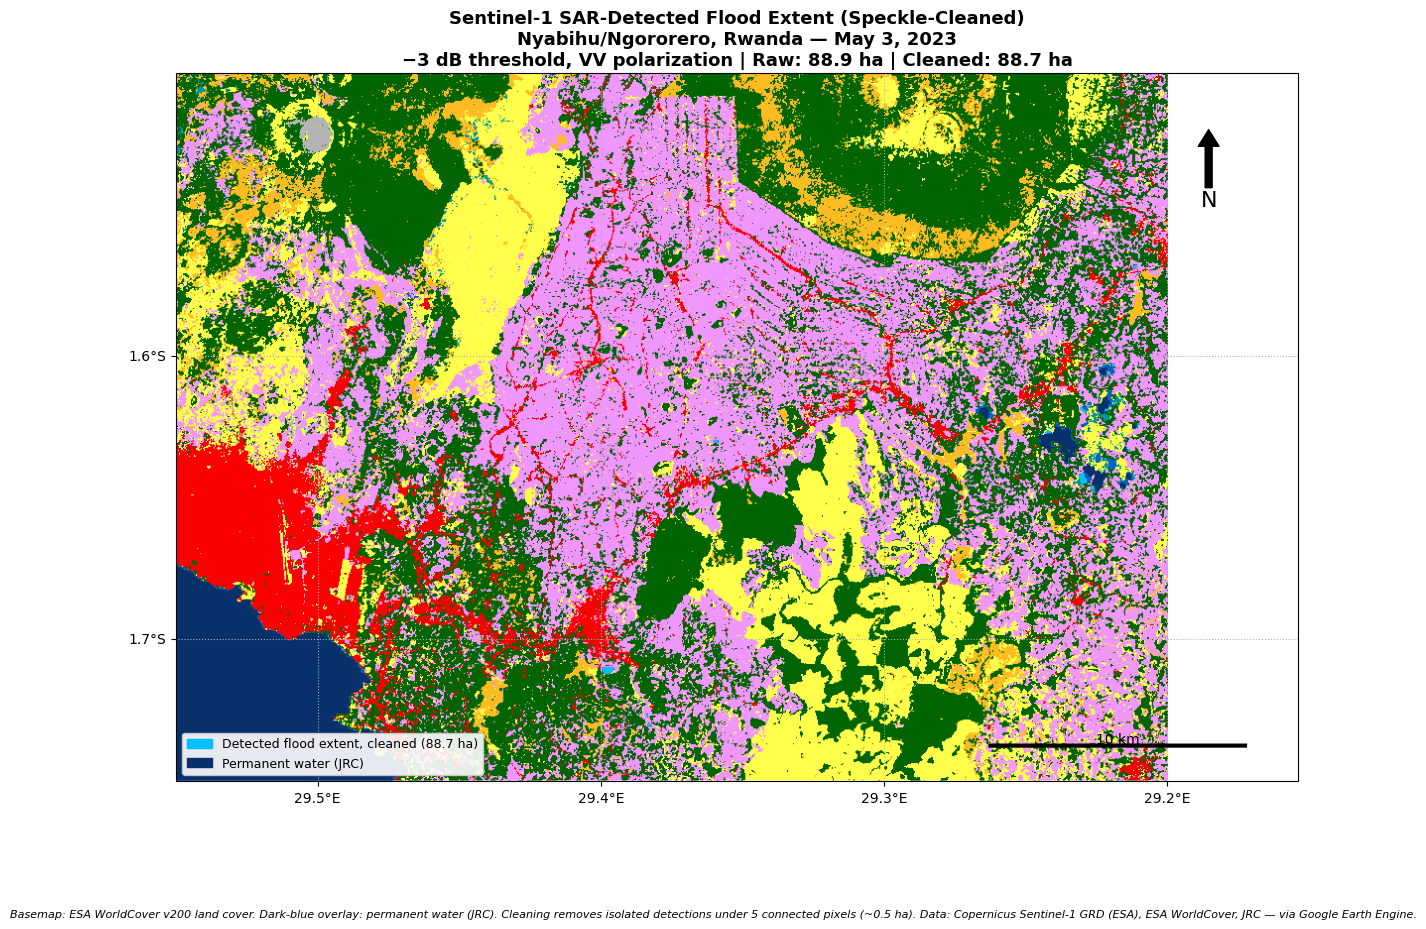

Saved as flood_extent_map_v2.png


In [22]:
# ============================================
# FLOOD EXTENT MAP v2 — real basemap, speckle-cleaned, dark-blob check
# Run in the same Colab session (reuses diff, aoi)
# ============================================

import ee
import geemap
from geemap import cartoee
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

region = [29.20, -1.75, 29.55, -1.50]

# ----------------------------------------------------------------
# STEP 1 — Identify what those two dark blobs actually are.
# Check permanent water (JRC) and steep slope (SRTM-derived) at those spots.
# ----------------------------------------------------------------
water = ee.Image('JRC/GSW1_4/GlobalSurfaceWater').select('occurrence')
water_mask = water.gt(50).selfMask()

srtm = ee.Image('USGS/SRTMGL1_003')
slope = ee.Terrain.slope(srtm)
steep_mask = slope.gt(25).selfMask()  # >25 degrees = plausible radar shadow zone

water_check = water_mask.clip(aoi).reduceRegion(
    reducer=ee.Reducer.count(), geometry=aoi, scale=30, maxPixels=1e9
).getInfo()
steep_check = steep_mask.clip(aoi).reduceRegion(
    reducer=ee.Reducer.count(), geometry=aoi, scale=30, maxPixels=1e9
).getInfo()

print('Permanent water pixels in AOI (JRC, 30m):', water_check)
print('Steep-slope (>25deg) pixels in AOI (SRTM, 30m):', steep_check)
print('-> Compare against the dark blob locations visually once mapped below.')
print('   If dark blobs align with steep-slope pixels: likely radar shadow, not water.')
print('   If dark blobs align with water pixels: likely a lake/crater lake.')

# ----------------------------------------------------------------
# STEP 2 — Speckle cleanup: remove isolated single/few-pixel detections.
# connectedPixelCount counts contiguous same-value pixels; we drop anything
# under a minimum patch size (here: 5 connected pixels = 0.5 hectares at 10m).
# ----------------------------------------------------------------
raw_flooded = diff.lt(-3).selfMask()

connected = raw_flooded.connectedPixelCount(25, True)  # search up to 25 px
min_patch_size = 5
flooded_clean = raw_flooded.updateMask(connected.gte(min_patch_size))

raw_area = raw_flooded.multiply(ee.Image.pixelArea()).divide(10000) \
    .reduceRegion(ee.Reducer.sum(), aoi, 10, maxPixels=1e9).get('VV').getInfo()
clean_area = flooded_clean.multiply(ee.Image.pixelArea()).divide(10000) \
    .reduceRegion(ee.Reducer.sum(), aoi, 10, maxPixels=1e9).get('VV').getInfo()

print(f'\nRaw flood extent (unfiltered): {raw_area:.2f} ha')
print(f'Cleaned flood extent (patches >= {min_patch_size} connected px only): {clean_area:.2f} ha')
print('Report BOTH numbers in the brief — do not silently replace 88.94 ha.')
print('Frame the cleaned version as "coherent flood patches" and the raw')
print('version as "all detected pixels, including isolated speckle."')

# ----------------------------------------------------------------
# STEP 3 — Build the map with real basemap + cleaned flood layer
# ----------------------------------------------------------------
# ESA WorldCover as real basemap context (forest/cropland/built-up/water)
worldcover = ee.ImageCollection('ESA/WorldCover/v200').first().clip(aoi)

fig = plt.figure(figsize=(12, 10))

ax = cartoee.get_map(worldcover, region=region, vis_params={'bands': ['Map']})

cartoee.add_layer(ax, flooded_clean, region=region, vis_params={'palette': ['#00BFFF']})
cartoee.add_layer(ax, water_mask.clip(aoi), region=region, vis_params={'palette': ['#08306b']})

cartoee.add_gridlines(ax, interval=[0.1, 0.1], linestyle=':')
cartoee.add_north_arrow(ax, text='N', xy=(0.92, 0.92), text_color='black',
                         arrow_color='black', fontsize=16)
cartoee.add_scale_bar_lite(ax, length=10, xy=(0.05, 0.05), fontsize=10,
                            color='black', unit='km')

legend_patches = [
    mpatches.Patch(color='#00BFFF', label=f'Detected flood extent, cleaned ({clean_area:.1f} ha)'),
    mpatches.Patch(color='#08306b', label='Permanent water (JRC)'),
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9, framealpha=0.9)

ax.set_title('Sentinel-1 SAR-Detected Flood Extent (Speckle-Cleaned)\n'
             'Nyabihu/Ngororero, Rwanda — May 3, 2023\n'
             f'−3 dB threshold, VV polarization | Raw: {raw_area:.1f} ha | Cleaned: {clean_area:.1f} ha',
             fontsize=13, fontweight='bold')

fig.text(0.5, 0.01,
         'Basemap: ESA WorldCover v200 land cover. Dark-blue overlay: permanent water (JRC). '
         'Cleaning removes isolated detections under 5 connected pixels (~0.5 ha). '
         'Data: Copernicus Sentinel-1 GRD (ESA), ESA WorldCover, JRC — via Google Earth Engine.',
         ha='center', fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('flood_extent_map_v2.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved as flood_extent_map_v2.png")

Zoomed region [W, S, E, N]: [27.97, -3.03, 31.03, 0.03]


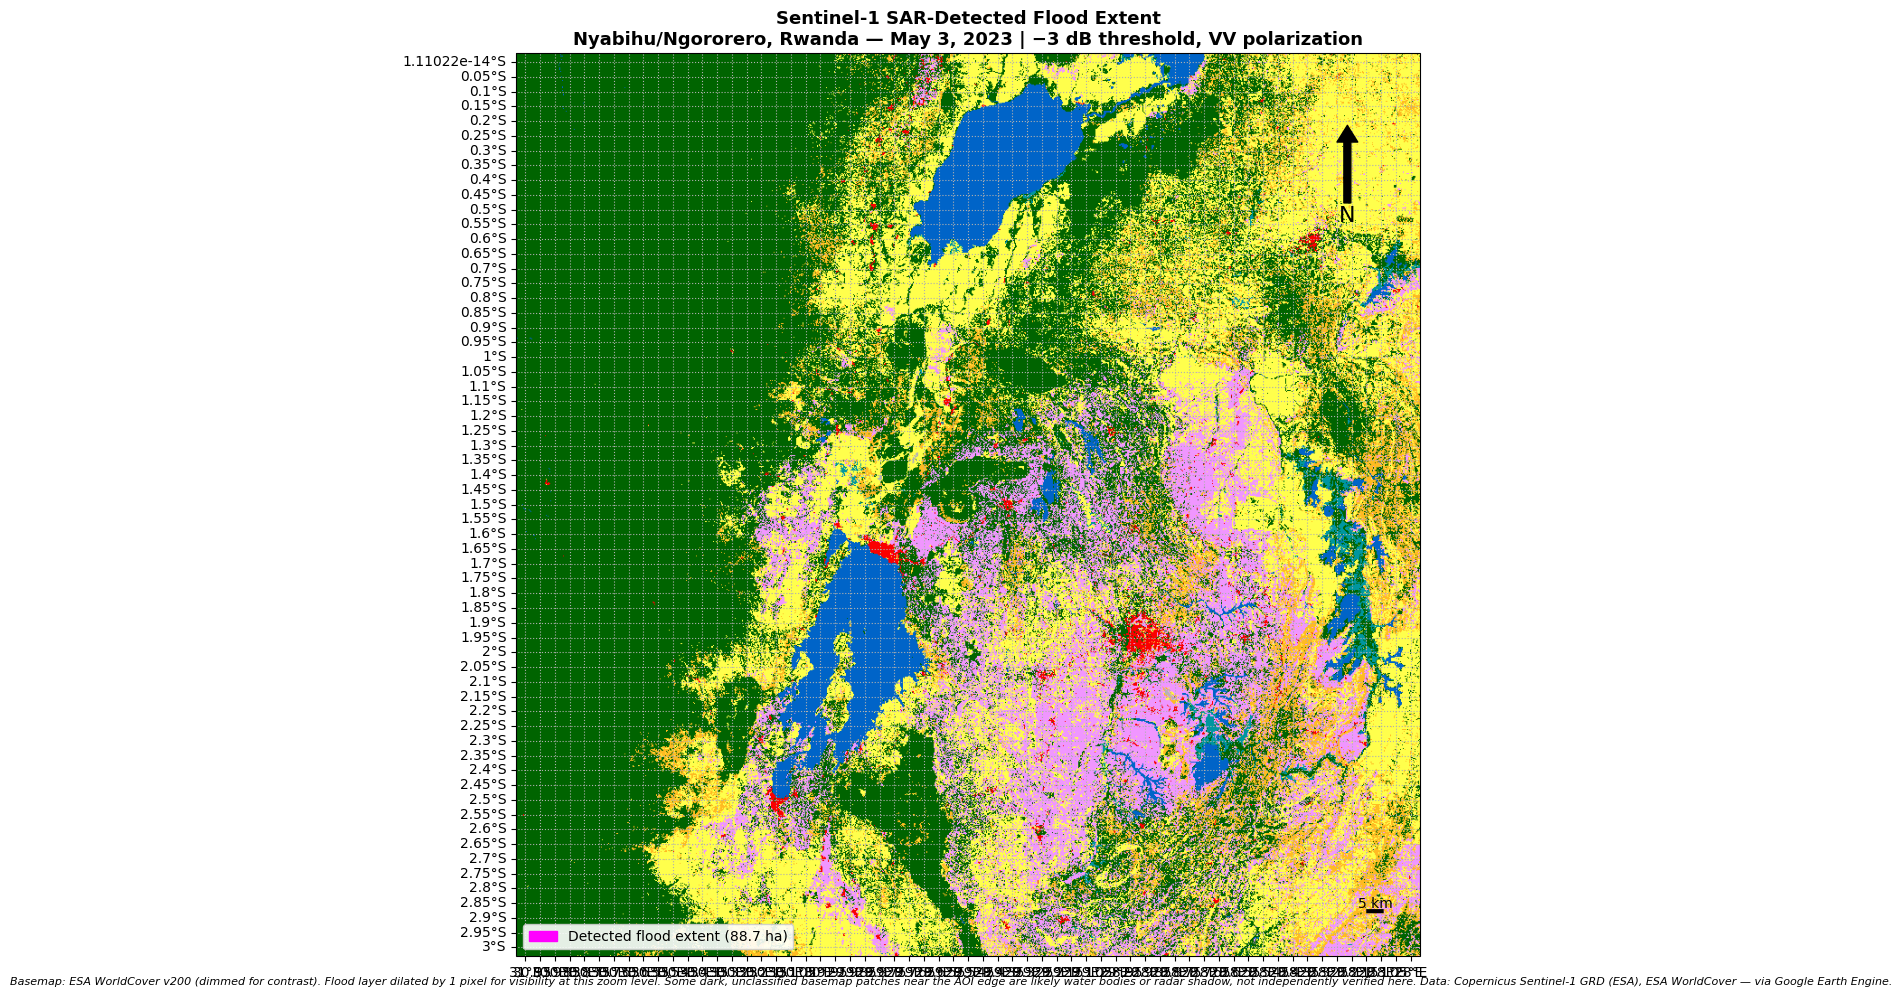

Saved as flood_extent_map_v3.png


In [23]:
# ============================================
# FLOOD EXTENT MAP v3 — zoomed to flood zone, high contrast
# Run in the same Colab session (reuses diff, aoi, flooded_clean, clean_area)
# ============================================

import ee
import geemap
from geemap import cartoee
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ----------------------------------------------------------------
# STEP 1 — Find the actual bounding box of the detected flood pixels,
# then pad it slightly, so the map zooms to where the action is.
# ----------------------------------------------------------------
flood_bounds = flooded_clean.geometry().bounds().getInfo()['coordinates'][0]
lons = [pt[0] for pt in flood_bounds]
lats = [pt[1] for pt in flood_bounds]
pad = 0.03  # ~3km padding around the flood cluster
zoom_region = [min(lons) - pad, min(lats) - pad, max(lons) + pad, max(lats) + pad]
print('Zoomed region [W, S, E, N]:', zoom_region)

# ----------------------------------------------------------------
# STEP 2 — Dilate the flood layer slightly so isolated pixels are
# visible at this zoom level instead of disappearing as single dots.
# ----------------------------------------------------------------
flooded_visible = flooded_clean.focal_max(1, 'square', 'pixels')

# ----------------------------------------------------------------
# STEP 3 — Build map: dimmed basemap + bold flood overlay
# ----------------------------------------------------------------
worldcover = ee.ImageCollection('ESA/WorldCover/v200').first().clip(
    ee.Geometry.Rectangle(zoom_region))

fig = plt.figure(figsize=(12, 10))
ax = cartoee.get_map(worldcover, region=zoom_region, vis_params={'bands': ['Map']}, alpha=0.5)

cartoee.add_layer(ax, flooded_visible, region=zoom_region,
                   vis_params={'palette': ['#FF00FF']})  # bold magenta — high contrast on any basemap

cartoee.add_gridlines(ax, interval=[0.05, 0.05], linestyle=':')
cartoee.add_north_arrow(ax, text='N', xy=(0.92, 0.92), text_color='black',
                         arrow_color='black', fontsize=16)
cartoee.add_scale_bar_lite(ax, length=5, xy=(0.05, 0.05), fontsize=10,
                            color='black', unit='km')

legend_patches = [
    mpatches.Patch(color='#FF00FF', label=f'Detected flood extent ({clean_area:.1f} ha)'),
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=10, framealpha=0.9)

ax.set_title('Sentinel-1 SAR-Detected Flood Extent\n'
             'Nyabihu/Ngororero, Rwanda — May 3, 2023 | −3 dB threshold, VV polarization',
             fontsize=13, fontweight='bold')

fig.text(0.5, 0.01,
         'Basemap: ESA WorldCover v200 (dimmed for contrast). Flood layer dilated by 1 pixel '
         'for visibility at this zoom level. Some dark, unclassified basemap patches near the '
         'AOI edge are likely water bodies or radar shadow, not independently verified here. '
         'Data: Copernicus Sentinel-1 GRD (ESA), ESA WorldCover — via Google Earth Engine.',
         ha='center', fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('flood_extent_map_v3.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved as flood_extent_map_v3.png")

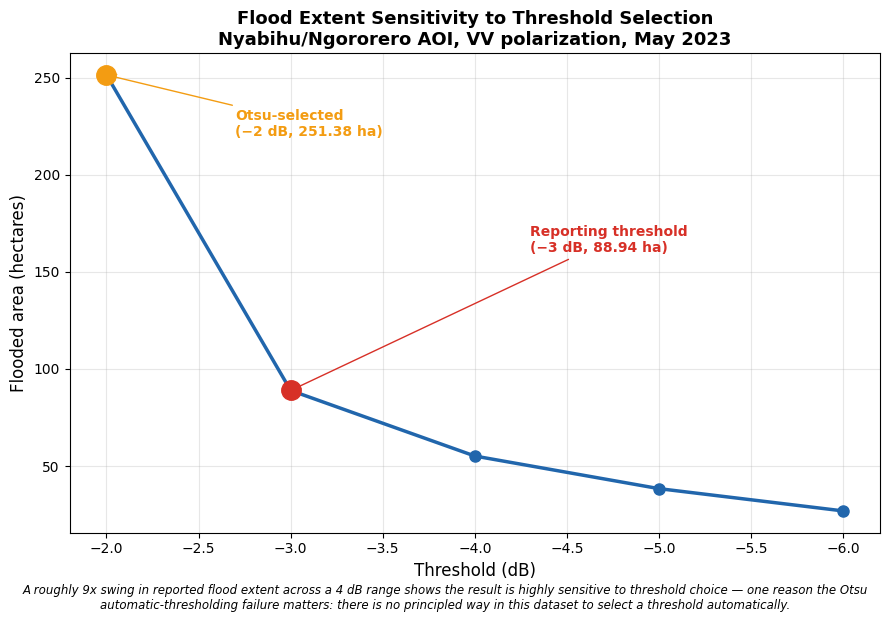

Saved as threshold_sensitivity_chart.png


In [24]:
# ============================================
# THRESHOLD SENSITIVITY CHART
# Plain matplotlib — no Earth Engine or cartoee needed for this one.
# Can run anywhere, even outside Colab, since the data is already known.
# ============================================

import matplotlib.pyplot as plt

thresholds = [-2, -3, -4, -5, -6]
areas_ha = [251.38, 88.94, 55.17, 38.38, 26.91]

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(thresholds, areas_ha, marker='o', markersize=8, linewidth=2.5,
        color='#2166ac')

# Highlight the reporting threshold
ax.plot(-3, 88.94, marker='o', markersize=14, color='#d73027', zorder=5)
ax.annotate('Reporting threshold\n(−3 dB, 88.94 ha)',
            xy=(-3, 88.94), xytext=(-4.3, 160),
            fontsize=10, fontweight='bold', color='#d73027',
            arrowprops=dict(arrowstyle='->', color='#d73027'))

# Mark where Otsu landed, for direct visual comparison
ax.plot(-2, 251.38, marker='o', markersize=14, color='#f39c12', zorder=5)
ax.annotate('Otsu-selected\n(−2 dB, 251.38 ha)',
            xy=(-2, 251.38), xytext=(-2.7, 220),
            fontsize=10, fontweight='bold', color='#f39c12',
            arrowprops=dict(arrowstyle='->', color='#f39c12'))

ax.set_xlabel('Threshold (dB)', fontsize=12)
ax.set_ylabel('Flooded area (hectares)', fontsize=12)
ax.set_title('Flood Extent Sensitivity to Threshold Selection\n'
             'Nyabihu/Ngororero AOI, VV polarization, May 2023',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.invert_xaxis()  # so -2 (least strict) reads left, -6 (most strict) reads right, matching increasing severity

fig.text(0.5, -0.02,
         'A roughly 9x swing in reported flood extent across a 4 dB range shows the result '
         'is highly sensitive to threshold choice — one reason the Otsu automatic-thresholding '
         'failure matters: there is no principled way in this dataset to select a threshold automatically.',
         ha='center', fontsize=8.5, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('threshold_sensitivity_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved as threshold_sensitivity_chart.png")